In [2]:
fig_num = 5 # change this to the figure number
analysis_name = "mpfc_motivation" # change this to the subfolder it should save to

In [3]:
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "4"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

# Define Data Files/Paths
subject = "wilbur"
date = "20210406"
file_name = subject + date
nwb_file_name = file_name + "_.nwb"

from spyglass.decoding.v1.c3po import Model
import matplotlib.pyplot as plt

# if date == "20210404":
#     marks_group_name = "mpfc1"
# else:
#     marks_group_name = "mpfc"

marks_group_name = "mpfc sorted spikes"
marks_group_name = "mpfc"
marks_group_name = "mpfc_HYBRID"
model_key = {
    "nwb_file_name": nwb_file_name,
    "marks_group_name": marks_group_name,
    "training_params_name":"wilbur_post_fix"
}

if "sorted_spikes" in marks_group_name:
    checkpoint = None
else:
    checkpoint = 6
analysis = (Model() & model_key).fetch_c3po_analysis(model_key, checkpoint=checkpoint)


from c3po.analysis.analysis import figure_directory
from pathlib import Path
first_epochs = False
fig_dir = Path(figure_directory) / f"Fig{fig_num}/{analysis_name}"/f"{subject}_{date}_{marks_group_name}"
if first_epochs:
    fig_dir = fig_dir / f"first_{first_epochs}_epochs"
fig_dir.mkdir(parents=True, exist_ok=True)

/home/sambray/.local/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82
[2026-10-01 10:26:30,009][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python

x shape (1, 34)
x shape (1, 32)


2026-10-01 10:26:50.480732: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-10-01 10:26:52.045225: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-10-01 10:26:54.015840: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
[2026-10-01 10:27:12,006][WARNING]: Skipped checksum for file

In [4]:
from spyglass.common import IntervalList
interval_query = IntervalList & (Model & model_key).proj(interval_list_name="training_interval_name")
run_epochs = interval_query.fetch1("valid_times")

if first_epochs:
    run_epochs = run_epochs[:first_epochs]


t_interp = [np.arange(start, end, 0.001) for start, end in run_epochs]
t_interp = np.concatenate(t_interp)
t_interp.shape
analysis.interpolate_context(t_interp)
# analysis.embed_context_pca()
analysis.fit_context_pca(fit_intervals = run_epochs)

# Load Data

### Trial and decoding dataframes

In [5]:
from utils.load_mpfc_data import fetch_behavioral_data, fetch_dio_times, fetch_decoding_df

behave_df_set = fetch_behavioral_data(nwb_file_name)
trial_df = behave_df_set["trial_df"]
alison_df = behave_df_set["alison_df"]

dio_intervals = fetch_dio_times(nwb_file_name)
all_pump_intervals = dio_intervals["all_pump_intervals"]
all_poke_intervals = dio_intervals["all_poke_intervals"]

decoding_df = fetch_decoding_df(nwb_file_name)


[10:31:08][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
	Use instead: table.fetch_nwb() method (logic integrated into FetchMixin)
[10:31:08][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use instead: FetchMixin.fetch_nwb() (logic integrated into mixin)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older 

### Position Data

In [6]:
# =========================================================
# POSITION / SPEED
# =========================================================
from spyglass.common import IntervalPositionInfo
from c3po.analysis.analysis import interval_list_contains_ind
key = {"nwb_file_name": nwb_file_name}

pos_key = {
    "nwb_file_name": nwb_file_name,
    # "interval_list_name": "pos 1 valid times",
    "position_info_param_name": "default",
}
query = IntervalPositionInfo & pos_key
pos_df = []
st_times = []
for k in query.fetch("KEY"):
    print(k)
    pos_df.append((IntervalPositionInfo & k).fetch1_dataframe())
    st_times.append(pos_df[-1].index.values[0])
st_times = np.array(st_times)
ind = np.argsort(st_times)
pos_df = [pos_df[i] for i in ind]
pos_df = pd.concat(pos_df)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 0 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 1 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 10 valid times'}


...

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 8 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


{'position_info_param_name': 'default', 'nwb_file_name': 'wilbur20210406_.nwb', 'interval_list_name': 'pos 9 valid times'}


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


### Sorted Spikes

In [7]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

key = {"nwb_file_name": nwb_file_name}
spikes_query = SortedSpikesGroup() & key
spikes_key = spikes_query.fetch1("KEY")
spikes, unit_ids = (spikes_query).fetch_spike_data(spikes_key, return_unit_ids=True)
unit_ids = np.array([f"{u['spikesorting_merge_id']}_{u['unit_id']}" for u in unit_ids])

[10:32:35][WARNING] Spyglass: Missing code for CurationV2
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-pa

## Monosynaptic

In [8]:
import os
os.chdir("/home/sambray/Documents/spyglass_custom/src/spyglass_custom/sambray")
from monosynaptic import Monosynaptic
from cross_correlogram import CrossCorrelogram, ShuffleCrossCorrelogram

cross_corr_key = {"cross_corr_params_name":"monosynaptic"}

mono_key = (Monosynaptic & spikes_key & {"monosynaptic_params_name": "default"}).fetch1("KEY")
neuron_types = (Monosynaptic & mono_key).get_neuron_types()
mono_df = (Monosynaptic & mono_key).fetch1_dataframe()


ambiguous = np.intersect1d(neuron_types["excitatory"], neuron_types["inhibitory"])
neuron_types["excitatory"] = np.array([i for i in neuron_types["excitatory"] if i not in ambiguous])
neuron_types["inhibitory"] = np.array([i for i in neuron_types["inhibitory"] if i not in ambiguous])
print(f"Ambiguous neurons: {ambiguous}")


# all_reciprical = []
# valid = []
# for id in neuron_types["inhibitory"]:
#     downstream_ids = mono_df[mono_df.unit_id_2 ==id].unit_id_1.values
#     recip_df = mono_df[mono_df.unit_id_2.isin(downstream_ids) & (mono_df.unit_id_1 == id)]
#     if len(recip_df) == len(downstream_ids):
#         all_reciprical.append(recip_df)
#     else:
#         valid.append(id)
# print(len(all_reciprical))
# print(len(valid))
# neuron_types["inhibitory"] = valid


corr_df = (CrossCorrelogram & mono_key).fetch1_dataframe()
shuffle_corr_df = (ShuffleCrossCorrelogram & spikes_key).fetch1_dataframe()
corr_df = corr_df.merge(shuffle_corr_df, on=["unit_id_1", "unit_id_2"], suffixes=("", "_shuffle"))
ind_neuron_type = {}
for type_, ids_ in neuron_types.items():
    ind_neuron_type[type_] = [np.where(unit_ids == i)[0][0] for i in ids_]
neuron_colors = {
    "excitatory": "cornflowerblue",
    "inhibitory":"firebrick"
}

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)


Ambiguous neurons: ['3a02e829-53d0-9dbf-0667-a44681becc44_92'
 '603ed441-252e-8393-270c-88a10f78b723_21'
 '603ed441-252e-8393-270c-88a10f78b723_26'
 '603ed441-252e-8393-270c-88a10f78b723_66'
 '940057ae-a68d-1236-9105-1b08c3c6db5b_16'
 '940057ae-a68d-1236-9105-1b08c3c6db5b_9'
 'b961ffc8-147a-6742-39a4-8b2950461d95_52'
 'b961ffc8-147a-6742-39a4-8b2950461d95_76'
 'eeabd812-8ace-5292-edf6-05c925a8b427_5'
 'efb8b6c7-4482-069c-78ba-55a5e52a92a3_28']


/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown2" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manage

# Embedding

In [9]:
motivation_pcs = (0,2)

# analysis.params['params']['embedding']['encoder']['encoder_matrix'].shape
param_source = analysis.params['params']['embedding']['encoder']
if "sorted_encoder" in param_source:
    param_source = param_source["sorted_encoder"]
W = param_source["encoder_matrix"]
W = W @ analysis.pca.components_.T

trial_mot_pcs = []
for trial in trial_df.itertuples():
    st = trial.run_start-.5
    en = trial.t_poke + .5
    ind_st = np.searchsorted(t_interp, st)
    ind_en = np.searchsorted(t_interp, en)
    trial_mot_pcs.append(analysis.c_pca_interp[ind_st:ind_en, motivation_pcs].mean(axis=0))
trial_mot_pcs = np.array(trial_mot_pcs)
trial_mot_angle = np.arctan2(trial_mot_pcs[:,0], -trial_mot_pcs[:,1])
# plt.scatter(trial_mot_pcs[:,0], trial_mot_pcs[:,1], c=trial_df.prev_trial_reward, cmap=plt.cm.coolwarm, alpha=0.5)
trial_df["motivation"] = trial_mot_angle

/tmp/ipykernel_1765547/111306566.py:16: RuntimeWarning: Mean of empty slice.
  trial_mot_pcs.append(analysis.c_pca_interp[ind_st:ind_en, motivation_pcs].mean(axis=0))


# Plot Pc's

In [10]:
def average_subsample(arr, n):
    end =  n * int(len(arr)/n)
    return np.mean(arr[:end].reshape(-1, n), 1)

def percentile_subsample(arr, n, percentiles):
    end =  n * int(len(arr)/n)
    return np.percentile(arr[:end].reshape(-1, n), percentiles, axis=1).T
# time_points = analysis.t_interp
# average_time = average(time_points, 1000)


/tmp/ipykernel_3464851/3991710033.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 0.94])


Text(0, 0.5, 'PC 3')

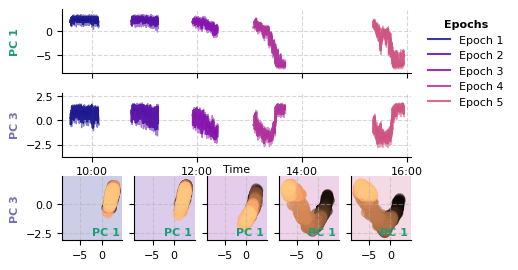

In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 8

# 1. Extract timestamps, PC0 (index 0), and PC2 (index 2)
time_points = analysis.t_interp
c_motivation = analysis.c_pca_interp[:, motivation_pcs]

# 2. Highly subsample the data streams identically
subsample_step = 3000
sub_c_mot = [percentile_subsample(c_motivation[:, i], subsample_step, [25, 50, 75])[:,None,:] for i in range(c_motivation.shape[1])]
sub_c_mot = np.column_stack(sub_c_mot)
sub_time = average_subsample(time_points, subsample_step)

# 3. Fixed height at 4.5 and widened width to match the 16:7 aspect ratio
# fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 4.5), sharex=True)
# fig_2d, axes_2d = plt.subplots(nrows=1, ncols=5, figsize=(10, 2), sharex=True, sharey=True)

fig = plt.figure(figsize = (4.5,3))
from matplotlib.gridspec import GridSpec
gs = GridSpec(3, 5, height_ratios=[1, 1, 1],
              hspace=0.3)
axes = [fig.add_subplot(gs[0, :])]
axes.append(fig.add_subplot(gs[1, :], sharex=axes[0]))
axes[0].tick_params(axis='x', labelbottom=False)
axes_2d = [fig.add_subplot(gs[2, 0])]
for i in range(1, 5):
    axes_2d.append(fig.add_subplot(gs[2, i], sharex=axes_2d[0], sharey=axes_2d[0]))
for ax in axes_2d[1:]:
    ax.tick_params(axis='y', labelleft=False)

# Continuous 'plasma' colormap setup
n_epochs = len(run_epochs)
cmap = plt.get_cmap("plasma")

# 4. Loop through each interval and plot sequentially on both axes
for i_epoch, (start, stop) in enumerate(run_epochs):
    # Create temporal mask for the current interval
    epoch_mask = (sub_time >= start +60) & (sub_time <= stop)

    # Ignore any NaN values present inside either data slice
    epoch_mask &= ~np.isnan(sub_time) & ~np.isnan(sub_c_mot).any(axis=1).any(axis=1)

    if not np.any(epoch_mask):
        continue

    plot_time = sub_time[epoch_mask]
    # plot_pc0 = sub_pc0[epoch_mask]
    # plot_pc2 = sub_pc2[epoch_mask]

    # Restrict color mapping to the first half (0.0 to 0.5)
    if n_epochs > 1:
        fraction = (i_epoch / (n_epochs - 1)) * 0.5
    else:
        fraction = 0.0

    epoch_color = cmap(fraction)
    epoch_label = f"Epoch {i_epoch + 1}"

    # Row 1: Plot Component 0
    axes[0].plot(
        plot_time, sub_c_mot[epoch_mask, 0,1],
        color=epoch_color,  linestyle="-", alpha=0.8, label=epoch_label
    )
    axes[0].fill_between(plot_time, sub_c_mot[epoch_mask, 0, 0], sub_c_mot[epoch_mask, 0, 2], color=epoch_color, alpha=0.5)

    # Row 2: Plot Component 2
    axes[1].plot(
        plot_time, sub_c_mot[epoch_mask, 1, 1],
        color=epoch_color, linestyle="-", alpha=0.8, label=epoch_label
    )
    axes[1].fill_between(plot_time, sub_c_mot[epoch_mask, 1, 0], sub_c_mot[epoch_mask, 1,2], color=epoch_color, alpha=0.5)

    axes_2d[i_epoch].scatter(sub_c_mot[epoch_mask, 0, 1], sub_c_mot[epoch_mask, 1, 1],
                             c=plot_time,cmap="copper",s=50,alpha=.5,edgecolor=None)

    epoch_color_rgba = np.array(epoch_color)
    epoch_color_rgba[-1] = 0.2 # Set alpha to 0.1 for the facecolor
    epoch_color = tuple(epoch_color_rgba)
    axes_2d[i_epoch].set_facecolor(epoch_color)

# 5. Finalize Axis Aesthetics and Legend Layout
# Global X-Limits shared by both plots
x_min, x_max = np.nanmin(sub_time) - 500, np.nanmax(sub_time) + 500
axes[1].set_xlim(x_min, x_max)

# Separate Y-limits to scale comfortably to their native bounds
axes[0].set_ylim(np.nanmin(sub_c_mot[:, 0]) - 1, np.nanmax(sub_c_mot[:, 0]) + 1)
axes[1].set_ylim(np.nanmin(sub_c_mot[:, 1]) - 1, np.nanmax(sub_c_mot[:, 1]) + 1)

# Format Labels
c0 = plt.cm.Dark2(motivation_pcs[0]/8)
c1 = plt.cm.Dark2(motivation_pcs[1]/8)
axes[0].set_ylabel(f"PC {motivation_pcs[0]+1}", color=c0, fontweight='bold')
axes[1].set_ylabel(f"PC {motivation_pcs[1]+1}", color=c1, fontweight='bold')
axes[1].set_xlabel("Time",va='bottom',labelpad=-2)

# Loop adjustments for grid and custom spine clipping boundaries
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.5)

# Place unified epoch tracker legend relative to the topmost row panel
axes[0].legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
    title="Epochs",
    title_fontproperties={'weight': 'bold'}
)

# Vertical labeling alignment execution across rows
fig.align_ylabels(axes)

# Elevate and center figure suptitle cleanly above layout canvas
# fig.suptitle("Day 3: Sorted Spikes Model PC 0 & PC 2 Across Epochs", fontsize=13, fontweight='bold', y=0.97)

from datetime import datetime
t_ticks = axes[1].get_xticks()
# tick_labels = [datetime.fromtimestamp(t).strftime("%H:%M") for t in t_ticks]
# axes[1].set_xticklabels(tick_labels)
dt = datetime.fromtimestamp(t_ticks[0])
new_dt = []
for hour in (10,12,14,16):
    new_dt.append(dt.replace(hour=hour, minute=0, second=0))
tick_labels = [datetime.strftime(dt, "%H:%M") for dt in new_dt]
tick_times = [dt.timestamp() for dt in new_dt]
axes[1].set_xticks(tick_times)
axes[1].set_xticklabels(tick_labels)

# for i, a in enumerate(axes):
#     a.set_facecolor(plt.cm.Dark2(motivation_pcs[i]/8))

# Manage bounding space to look nice on the new wide format
plt.tight_layout(rect=[0, 0, 0.88, 0.94])
# plt.show()



ax = axes_2d[0]
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xlim = (xlim[0] - 0.1 * (xlim[1] - xlim[0]), xlim[1] + 0.1 * (xlim[1] - xlim[0])
        )
ylim = (ylim[0] - 0.1 * (ylim[1] - ylim[0]), ylim[1] + 0.1 * (ylim[1] - ylim[0])
        )
ax.set_xlim(xlim)
ax.set_ylim(ylim)
# 2d axes formatting
for ax in axes_2d:
    # ax.set_xlabel("PC 1")
    # ax.set_ylabel("PC 2")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, linestyle="--", alpha=0.5)
    xlims = ax.get_xlim()
    ylims = ax.get_ylim()


    xloc = xlims[0] + 0.95 * (xlims[1] - xlims[0])
    yloc = ylims[0] + 0.05 * (ylims[1] - ylims[0])
    ax.text(xloc, yloc, f"PC {motivation_pcs[0]+1}", color=c0, fontweight='bold',
            ha='right', va='bottom', fontsize=8)
# axes_2d[2].set_xlabel(f"PC {motivation_pcs[0]+1}",color=c0, fontweight='bold')
axes_2d[0].set_ylabel(f"PC {motivation_pcs[1]+1}",color=c1, fontweight='bold')
# fig_2d.savefig(fig_dir/"motivation_pcs_2d.svg")

# fig.savefig(fig_dir/"motivation_pcs.svg")
# fig_2d.savefig(fig_dir/"motivation_pcs_2d.svg")

# fig.savefig(fig_dir/"motivation_pcs_combined.svg")

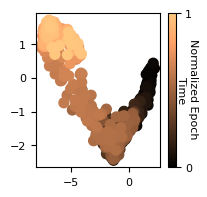

In [12]:
fig_2d_colorbar = plt.figure(figsize=(2,2))
ax = fig_2d_colorbar.add_subplot(111)

norm_time = (plot_time - np.nanmin(plot_time)) / (np.nanmax(plot_time) - np.nanmin(plot_time))
cb = ax.scatter(sub_c_mot[epoch_mask, 0, 1], sub_c_mot[epoch_mask, 1, 1],
                             c=norm_time,cmap="copper",s=50,alpha=1,edgecolor=None, )
cbar = plt.colorbar(cb, ax=ax, ticks=[0, 1],)
cbar.set_label("Normalized Epoch \nTime",rotation=270)
fig_2d_colorbar.savefig(fig_dir/"motivation_pcs_2d_colorbar.svg")

# Spiking results

In [13]:
W = param_source["encoder_matrix"]
W = W @ analysis.pca.components_.T
W_dim = W[:, motivation_pcs]
W_angle = np.arctan2(W_dim[:, 0], W_dim[:, 1])
W_mag = np.sum((W_dim**2), axis=1)**.5

sig_thresh = .1
step_size = 10.0      # Resolution of each column on the heatmap
window_size = 60.0    # Smoothing width
half_window = window_size / 2.0

/tmp/ipykernel_3464851/2434263937.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 0.91, 0.94])


Text(0.5, -0.06, 'Consecutive Run Time Bins (10s steps, 30s centered moving average windows)')

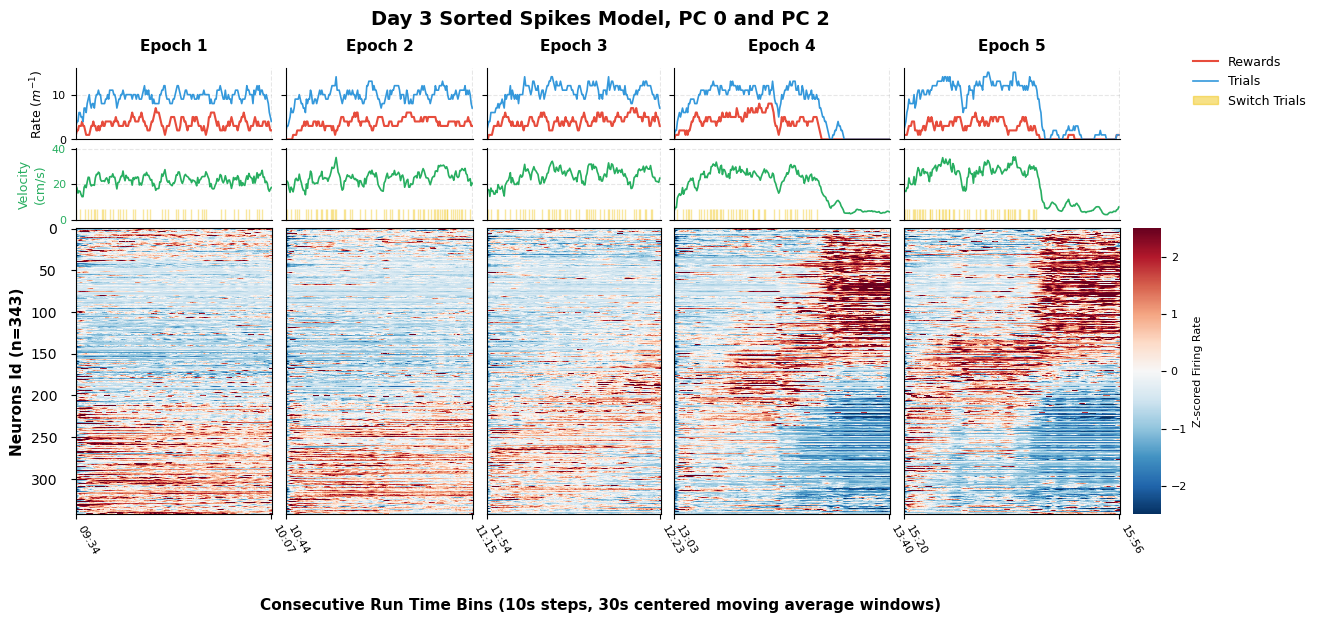

In [14]:
from scipy.stats import zscore
from matplotlib.patches import Patch
import seaborn as sns

t_pos = pos_df.index.values
speed = pos_df["head_speed"].values

# --- 1. Filter neurons based on tuning weights ---
significant_idx = np.where(W_mag > sig_thresh)[0]
tuned_weights = W_angle[significant_idx]
tuned_spikes = [spikes[i] for i in significant_idx]

n_neurons = len(tuned_spikes)
n_epochs = len(run_epochs)

# Extract behavioral timestamps from trial_df
rewarded_trials = trial_df[trial_df["reward"] == 1]
reward_times = rewarded_trials["t_poke"].values
all_trial_times = trial_df["t_poke"].values

# Get switch trial choice timestamps
switch_trials = trial_df[trial_df["n_pre_switch"] == 0]
switch_times = switch_trials["t_choice"].values

# --- 2. Compute Metrics using a Centered 30s Moving Average ---
epoch_firing_rates = []
epoch_reward_counts = []
epoch_trial_counts = []
epoch_mean_speeds = []
epoch_bin_definitions = []

for i_ep, (start, stop) in enumerate(run_epochs):
    all_epoch_spikes = []
    for spike_times in tuned_spikes:
        valid_spikes = spike_times[(spike_times >= start) & (spike_times <= stop)]
        if len(valid_spikes) > 0:
            all_epoch_spikes.append(np.min(valid_spikes))

    if len(all_epoch_spikes) == 0:
        continue

    first_spike_time = np.min(all_epoch_spikes)

    bin_centers = np.arange(start + half_window, stop - half_window + step_size, step_size)

    epoch_bins = []
    for center in bin_centers:
        b_start = max(start, center - half_window)
        b_end = min(stop, center + half_window)
        if b_end > first_spike_time:
            epoch_bins.append((b_start, b_end))

    n_epoch_bins = len(epoch_bins)
    if n_epoch_bins == 0:
        continue

    epoch_bin_definitions.append(epoch_bins)

    rates = np.zeros((n_neurons, n_epoch_bins))
    rewards_per_bin = np.zeros(n_epoch_bins)
    trials_per_bin = np.zeros(n_epoch_bins)
    speed_per_bin = np.zeros(n_epoch_bins)

    for b_idx, (b_start, b_end) in enumerate(epoch_bins):
        for n_idx, spike_times in enumerate(tuned_spikes):
            st_spike = np.searchsorted(spike_times,b_start)
            end_spike = np.searchsorted(spike_times[st_spike:],b_end)+st_spike
            n_spikes = end_spike - st_spike
            rates[n_idx, b_idx] = n_spikes / (b_end - b_start)

        rewards_per_bin[b_idx] = np.sum((reward_times >= b_start) & (reward_times < b_end))
        trials_per_bin[b_idx] = np.sum((all_trial_times >= b_start) & (all_trial_times < b_end))


        if len(t_pos) > 0:
            spatial_mask = (t_pos >= b_start) & (t_pos < b_end)
            if np.any(spatial_mask):
                speed_per_bin[b_idx] = np.nanmean(speed[spatial_mask])
            else:
                speed_per_bin[b_idx] = 0.0
        else:
            speed_per_bin[b_idx] = 0.0

    trial_scaling = window_size / 60.0 # converts to rewards / minute
    epoch_firing_rates.append(rates)
    epoch_reward_counts.append(rewards_per_bin * trial_scaling)
    epoch_trial_counts.append(trials_per_bin * trial_scaling)
    epoch_mean_speeds.append(speed_per_bin)

# --- 3. Custom Phase/Polar Sorting Sequence (CURRENT INVERSE SELECTION) ---
all_firing_rates = np.hstack(epoch_firing_rates)

pos_mask = tuned_weights >= 0
neg_mask = tuned_weights < 0

pos_indices = np.where(pos_mask)[0]
neg_indices = np.where(neg_mask)[0]

# Positives: Least to most positive (ascending)
sort_pos = pos_indices[np.argsort(tuned_weights[pos_indices])]
# Negatives: Most to least negative (ascending)
sort_neg = neg_indices[np.argsort(tuned_weights[neg_indices])]

# Combine blocks sequentially
forward_order_idx = np.concatenate([sort_pos, sort_neg])

# INVERSE ACTION: Invert the exact order chain backwards
custom_order_idx = forward_order_idx[::-1]
sorted_all_rates = all_firing_rates[custom_order_idx, :]

z_scored_all = zscore(sorted_all_rates, axis=1)

epoch_segments = []
current_col = 0
for rates in epoch_firing_rates:
    n_bins_in_epoch = rates.shape[1]
    segment = z_scored_all[:, current_col : current_col + n_bins_in_epoch]
    epoch_segments.append(segment)
    current_col += n_bins_in_epoch

# --- 4. Plot 3-Row Multi-Panel Layout (16:7 Aspect Ratio Profile) ---
widths = [seg.shape[1] for seg in epoch_segments]
n_active_epochs = len(epoch_segments)

fig = plt.figure(figsize=(14, 5.8))

sub_grids = fig.add_gridspec(
    nrows=3, ncols=n_active_epochs + 1,
    width_ratios=widths + [max(1, sum(widths)//35)],
    height_ratios=[1, 1, 4],
    wspace=0.08, hspace=0.06
)

max_behavior = max([np.max(np.maximum(r, t)) for r, t in zip(epoch_reward_counts, epoch_trial_counts)]) if len(epoch_reward_counts) > 0 else 5
behavior_ylim = (0, max_behavior + 1)

max_speed_val = max([np.max(s) for s in epoch_mean_speeds]) if len(epoch_mean_speeds) > 0 else 30
speed_ylim = (0, max_speed_val + 5)

cbar_ax = fig.add_subplot(sub_grids[2, -1])
heatmap_axes = []

line_rew, line_tri = None, None

for i_ep in range(n_active_epochs):
    ax_behavior = fig.add_subplot(sub_grids[0, i_ep])
    ax_speed = fig.add_subplot(sub_grids[1, i_ep], sharex=ax_behavior)
    ax_heatmap = fig.add_subplot(sub_grids[2, i_ep], sharex=ax_behavior)

    heatmap_axes.append(ax_heatmap)
    bin_indices = np.arange(len(epoch_reward_counts[i_ep]))

    # ------------------------------------
    # Row 0: Behavioral Metrics Plot
    # ------------------------------------
    line_rew, = ax_behavior.plot(bin_indices, epoch_reward_counts[i_ep], color="#e74c3c", linewidth=1.5, label="Rewards")
    line_tri, = ax_behavior.plot(bin_indices, epoch_trial_counts[i_ep], color="#3498db", linewidth=1.2, label="Trials")

    ax_behavior.set_ylim(behavior_ylim)
    ax_behavior.set_title(f"Epoch {i_ep + 1}", fontsize=11, fontweight='bold', pad=12)
    ax_behavior.grid(True, linestyle="--", alpha=0.3)
    ax_behavior.spines[["top", "right"]].set_visible(False)
    ax_behavior.tick_params(axis='x', labelbottom=False, bottom=False)

    if i_ep == 0:
        ax_behavior.set_ylabel("Rate ($m^{-1}$)", fontsize=9)
    else:
        ax_behavior.tick_params(axis='y', labelleft=False)

    # ------------------------------------
    # Row 1: Velocity Plot with Skinny Switch Blips
    # ------------------------------------
    ax_speed.plot(bin_indices, epoch_mean_speeds[i_ep], color="#27ae60", linewidth=1.2)
    ax_speed.set_ylim(speed_ylim)
    ax_speed.grid(True, linestyle="--", alpha=0.3)
    ax_speed.spines[["top", "right"]].set_visible(False)
    ax_speed.tick_params(axis='x', labelbottom=False, bottom=False)

    current_bins = epoch_bin_definitions[i_ep]
    for switch_t in switch_times:
        for b_idx, (b_start, b_end) in enumerate(current_bins):
            if b_start <= switch_t < b_end:
                ax_speed.vlines(x=b_idx, ymin=0, ymax=speed_ylim[1]*0.15,
                                color="#f1c40f", alpha=0.4, linewidth=1.0, zorder=1)
                break

    if i_ep == 0:
        ax_speed.set_ylabel("Velocity\n(cm/s)", color="#27ae60", fontsize=9)
        ax_speed.tick_params(axis='y', labelcolor="#27ae60")
    else:
        ax_speed.tick_params(axis='y', labelleft=False)

    # ------------------------------------
    # Row 2: Neuronal Heatmap Matrix
    # ------------------------------------
    show_cbar = (i_ep == n_active_epochs - 1)

    sns.heatmap(
        epoch_segments[i_ep],
        cmap="RdBu_r",
        vmin=-2.5, vmax=2.5,
        cbar=show_cbar,
        cbar_ax=cbar_ax if show_cbar else None,
        ax=ax_heatmap,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={'label': 'Z-scored Firing Rate'} if show_cbar else None,
        rasterized=True
    )

    if i_ep == 0:
        major_ticks = np.arange(0, n_neurons, 50)
        ax_heatmap.set_yticks(major_ticks + 0.5)
        # FIXED: Forces text limits to horizontally justify to the right edge and line up flawlessly
        ax_heatmap.set_yticklabels([str(t) for t in major_ticks], rotation=0, fontsize=10, ha='right')
        ax_heatmap.tick_params(axis='y', left=True, pad=10)
    else:
        ax_heatmap.tick_params(axis='y', left=False)

    x_ticks = [0, len(epoch_bin_definitions[i_ep]) - 1]
    tick_times = run_epochs[i_ep]
    tick_times = [datetime.fromtimestamp(t) for t in tick_times]
    tick_labels = [t.strftime("%H:%M") for t in tick_times]
    ax_heatmap.set_xticks(x_ticks)
    ax_heatmap.set_xticklabels(tick_labels,rotation=-60, ha="left")

    # REMOVED: ax_heatmap.axhline (Dotted horizontal indicator line removed)
    ax_heatmap.spines[:].set_visible(True)

# --- Global Side Legend Placement Container ---
if line_rew and line_tri:
    # Build proxy handle representation to include switch blips track cleanly
    patch_switch = Patch(color="#f1c40f", alpha=0.5, label="Switch Trials")

    fig.legend(
        handles=[line_rew, line_tri, patch_switch],
        loc="upper left",
        bbox_to_anchor=(0.915, 0.92),
        frameon=False,
        fontsize=9
    )

# Global Layout and Updated Y-Label Context Definition
heatmap_axes[0].set_ylabel(f"Neurons Id (n={n_neurons})", fontsize=11, fontweight='bold')
fig.suptitle("Day 3 Sorted Spikes Model, PC 0 and PC 2", fontsize=14, fontweight='bold', y=0.98)

# Finely controlled rect bounds coordinates pull everything together
plt.tight_layout(rect=[0, 0.05, 0.91, 0.94])
fig.supxlabel("Consecutive Run Time Bins (10s steps, 30s centered moving average windows)", fontsize=11, fontweight='bold', y=-0.06)

# fig.savefig(fig_dir / "motivation_firing_rates.svg",)

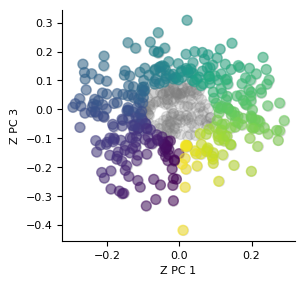

In [39]:
fig = plt.figure(figsize=(3,3))
ax = fig.add_subplot(111)

s=50
ax.scatter(W_dim[:,0], W_dim[:,1],c="grey",s=s,alpha=.2)

ind_sig = np.where(W_mag > sig_thresh)
plt.scatter(W_dim[ind_sig,0], W_dim[ind_sig,1],c=W_angle[ind_sig],s=s,alpha=.5)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel(f"Z PC {motivation_pcs[0]+1}")
ax.set_ylabel(f"Z PC {motivation_pcs[1]+1}")
fig.savefig(fig_dir / f"neuron_motivation_embeddings.svg")

# Inhibitory / Excitatory

In [266]:

method="zscore"
method="fold_change"
sig_thresh = .05

In [267]:
neuron_type = "inhibitory"
t_pos = pos_df.index.values
speed = pos_df["head_speed"].values

# --- 1. Filter neurons based on tuning weights ---
significant_idx = np.where(W_mag > sig_thresh)[0]
type_idx =ind_neuron_type[neuron_type]
significant_idx = np.intersect1d(significant_idx, type_idx)
tuned_weights = W_angle[significant_idx]
tuned_spikes = [spikes[i] for i in significant_idx]

n_neurons = len(tuned_spikes)
n_epochs = len(run_epochs)

# Extract behavioral timestamps from trial_df
rewarded_trials = trial_df[trial_df["reward"] == 1]
reward_times = rewarded_trials["t_poke"].values
all_trial_times = trial_df["t_poke"].values

# Get switch trial choice timestamps
switch_trials = trial_df[trial_df["n_pre_switch"] == 0]
switch_times = switch_trials["t_choice"].values

# --- 2. Compute Metrics using a Centered 30s Moving Average ---
epoch_firing_rates = []
epoch_reward_counts = []
epoch_trial_counts = []
epoch_mean_speeds = []
epoch_bin_definitions = []

for i_ep, (start, stop) in enumerate(run_epochs):
    all_epoch_spikes = []
    for spike_times in tuned_spikes:
        valid_spikes = spike_times[(spike_times >= start) & (spike_times <= stop)]
        if len(valid_spikes) > 0:
            all_epoch_spikes.append(np.min(valid_spikes))

    if len(all_epoch_spikes) == 0:
        continue

    first_spike_time = np.min(all_epoch_spikes)

    bin_centers = np.arange(start + half_window, stop - half_window + step_size, step_size)

    epoch_bins = []
    for center in bin_centers:
        b_start = max(start, center - half_window)
        b_end = min(stop, center + half_window)
        if b_end > first_spike_time:
            epoch_bins.append((b_start, b_end))

    n_epoch_bins = len(epoch_bins)
    if n_epoch_bins == 0:
        continue

    epoch_bin_definitions.append(epoch_bins)

    rates = np.zeros((n_neurons, n_epoch_bins))
    rewards_per_bin = np.zeros(n_epoch_bins)
    trials_per_bin = np.zeros(n_epoch_bins)
    speed_per_bin = np.zeros(n_epoch_bins)

    for b_idx, (b_start, b_end) in enumerate(epoch_bins):
        for n_idx, spike_times in enumerate(tuned_spikes):
            st_spike = np.searchsorted(spike_times,b_start)
            end_spike = np.searchsorted(spike_times[st_spike:],b_end)+st_spike
            n_spikes = end_spike - st_spike
            rates[n_idx, b_idx] = n_spikes / (b_end - b_start)

        rewards_per_bin[b_idx] = np.sum((reward_times >= b_start) & (reward_times < b_end))
        trials_per_bin[b_idx] = np.sum((all_trial_times >= b_start) & (all_trial_times < b_end))


        if len(t_pos) > 0:
            spatial_mask = (t_pos >= b_start) & (t_pos < b_end)
            if np.any(spatial_mask):
                speed_per_bin[b_idx] = np.nanmean(speed[spatial_mask])
            else:
                speed_per_bin[b_idx] = 0.0
        else:
            speed_per_bin[b_idx] = 0.0

    trial_scaling = window_size / 60.0 # converts to rewards / minute
    epoch_firing_rates.append(rates)
    epoch_reward_counts.append(rewards_per_bin * trial_scaling)
    epoch_trial_counts.append(trials_per_bin * trial_scaling)
    epoch_mean_speeds.append(speed_per_bin)

# --- 3. Custom Phase/Polar Sorting Sequence (CURRENT INVERSE SELECTION) ---
all_firing_rates = np.hstack(epoch_firing_rates)

pos_mask = tuned_weights >= 0
neg_mask = tuned_weights < 0

pos_indices = np.where(pos_mask)[0]
neg_indices = np.where(neg_mask)[0]

# Positives: Least to most positive (ascending)
sort_pos = pos_indices[np.argsort(tuned_weights[pos_indices])]
# Negatives: Most to least negative (ascending)
sort_neg = neg_indices[np.argsort(tuned_weights[neg_indices])]

# Combine blocks sequentially
forward_order_idx = np.concatenate([sort_pos, sort_neg])

# INVERSE ACTION: Invert the exact order chain backwards
custom_order_idx = forward_order_idx[::-1]
sorted_all_rates = all_firing_rates[custom_order_idx, :]

if method == "zscore":
    print("HI")
    z_scored_all = zscore(sorted_all_rates, axis=1)
elif method == "fold_change":
    baseline = np.mean(sorted_all_rates, axis=1, keepdims=True)
    z_scored_all = (sorted_all_rates) / (baseline + 1e-6)
    z_scored_all = np.log2(z_scored_all + 1e-6)
# z_scored_all = zscore(sorted_all_rates, axis=1)
epoch_segments_inhibitory = []
epoch_segments_inhibitory_mean = []
current_col = 0
for rates in epoch_firing_rates:
    n_bins_in_epoch = rates.shape[1]
    segment = z_scored_all[:, current_col : current_col + n_bins_in_epoch]
    segment_mean = np.mean(sorted_all_rates[:, current_col : current_col + n_bins_in_epoch], axis=1)
    epoch_segments_inhibitory.append(segment)
    current_col += n_bins_in_epoch
    epoch_segments_inhibitory_mean.append(segment_mean)

n_neurons_inhibitory = n_neurons

In [268]:
neuron_type = "excitatory"
t_pos = pos_df.index.values
speed = pos_df["head_speed"].values

# --- 1. Filter neurons based on tuning weights ---
significant_idx = np.where(W_mag > sig_thresh)[0]
type_idx =ind_neuron_type[neuron_type]
significant_idx = np.intersect1d(significant_idx, type_idx)
tuned_weights = W_angle[significant_idx]
tuned_spikes = [spikes[i] for i in significant_idx]

n_neurons = len(tuned_spikes)
n_epochs = len(run_epochs)

# Extract behavioral timestamps from trial_df
rewarded_trials = trial_df[trial_df["reward"] == 1]
reward_times = rewarded_trials["t_poke"].values
all_trial_times = trial_df["t_poke"].values

# Get switch trial choice timestamps
switch_trials = trial_df[trial_df["n_pre_switch"] == 0]
switch_times = switch_trials["t_choice"].values

# --- 2. Compute Metrics using a Centered 30s Moving Average ---
epoch_firing_rates = []
epoch_reward_counts = []
epoch_trial_counts = []
epoch_mean_speeds = []
epoch_bin_definitions = []

for i_ep, (start, stop) in enumerate(run_epochs):
    all_epoch_spikes = []
    for spike_times in tuned_spikes:
        valid_spikes = spike_times[(spike_times >= start) & (spike_times <= stop)]
        if len(valid_spikes) > 0:
            all_epoch_spikes.append(np.min(valid_spikes))

    if len(all_epoch_spikes) == 0:
        continue

    first_spike_time = np.min(all_epoch_spikes)

    bin_centers = np.arange(start + half_window, stop - half_window + step_size, step_size)

    epoch_bins = []
    for center in bin_centers:
        b_start = max(start, center - half_window)
        b_end = min(stop, center + half_window)
        if b_end > first_spike_time:
            epoch_bins.append((b_start, b_end))

    n_epoch_bins = len(epoch_bins)
    if n_epoch_bins == 0:
        continue

    epoch_bin_definitions.append(epoch_bins)

    rates = np.zeros((n_neurons, n_epoch_bins))
    rewards_per_bin = np.zeros(n_epoch_bins)
    trials_per_bin = np.zeros(n_epoch_bins)
    speed_per_bin = np.zeros(n_epoch_bins)

    for b_idx, (b_start, b_end) in enumerate(epoch_bins):
        for n_idx, spike_times in enumerate(tuned_spikes):
            st_spike = np.searchsorted(spike_times,b_start)
            end_spike = np.searchsorted(spike_times[st_spike:],b_end)+st_spike
            n_spikes = end_spike - st_spike
            rates[n_idx, b_idx] = n_spikes / (b_end - b_start)

        rewards_per_bin[b_idx] = np.sum((reward_times >= b_start) & (reward_times < b_end))
        trials_per_bin[b_idx] = np.sum((all_trial_times >= b_start) & (all_trial_times < b_end))


        if len(t_pos) > 0:
            spatial_mask = (t_pos >= b_start) & (t_pos < b_end)
            if np.any(spatial_mask):
                speed_per_bin[b_idx] = np.nanmean(speed[spatial_mask])
            else:
                speed_per_bin[b_idx] = 0.0
        else:
            speed_per_bin[b_idx] = 0.0

    trial_scaling = window_size / 60.0 # converts to rewards / minute
    epoch_firing_rates.append(rates)
    epoch_reward_counts.append(rewards_per_bin * trial_scaling)
    epoch_trial_counts.append(trials_per_bin * trial_scaling)
    epoch_mean_speeds.append(speed_per_bin)

# --- 3. Custom Phase/Polar Sorting Sequence (CURRENT INVERSE SELECTION) ---
all_firing_rates = np.hstack(epoch_firing_rates)

pos_mask = tuned_weights >= 0
neg_mask = tuned_weights < 0

pos_indices = np.where(pos_mask)[0]
neg_indices = np.where(neg_mask)[0]

# Positives: Least to most positive (ascending)
sort_pos = pos_indices[np.argsort(tuned_weights[pos_indices])]
# Negatives: Most to least negative (ascending)
sort_neg = neg_indices[np.argsort(tuned_weights[neg_indices])]

# Combine blocks sequentially
forward_order_idx = np.concatenate([sort_pos, sort_neg])

# INVERSE ACTION: Invert the exact order chain backwards
custom_order_idx = forward_order_idx[::-1]
sorted_all_rates = all_firing_rates[custom_order_idx, :]

# z_scored_all = zscore(sorted_all_rates, axis=1)
if method == "zscore":
    print("HI")
    z_scored_all = zscore(sorted_all_rates, axis=1)
elif method == "fold_change":
    baseline = np.mean(sorted_all_rates, axis=1, keepdims=True)
    z_scored_all = (sorted_all_rates) / (baseline + 1e-6)
    z_scored_all = np.log2(z_scored_all + 1e-6)

epoch_segments_excitatory = []
epoch_segments_excitatory_mean = []
current_col = 0
for rates in epoch_firing_rates:
    n_bins_in_epoch = rates.shape[1]
    segment = z_scored_all[:, current_col : current_col + n_bins_in_epoch]
    segment_mean = np.mean(sorted_all_rates[:, current_col : current_col + n_bins_in_epoch], axis=1)
    epoch_segments_excitatory.append(segment)
    epoch_segments_excitatory_mean.append(segment_mean)
    current_col += n_bins_in_epoch

n_neurons_excitatory = n_neurons

/tmp/ipykernel_3464851/3214115698.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 0.91, 0.94])


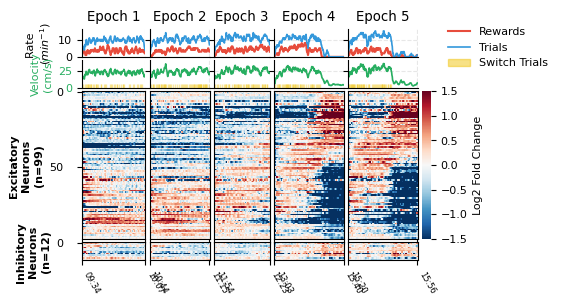

In [269]:
from scipy.stats import zscore
from matplotlib.patches import Patch
import seaborn as sns



# --- 4. Plot 3-Row Multi-Panel Layout (16:7 Aspect Ratio Profile) ---
widths = [seg.shape[1] for seg in epoch_segments]
n_active_epochs = len(epoch_segments)

# fig = plt.figure(figsize=(14, 8))
fig = plt.figure(figsize=(4.5,3))
fract_excitatory = n_neurons_excitatory / (n_neurons_excitatory + n_neurons_inhibitory)
fract_inhibitory = n_neurons_inhibitory / (n_neurons_excitatory + n_neurons_inhibitory)
sub_grids = fig.add_gridspec(
    nrows=4, ncols=n_active_epochs + 1,
    width_ratios=widths + [max(1, sum(widths)//35)],
    height_ratios=[1, 1, 6*fract_excitatory, 6*fract_inhibitory],
    wspace=0.08, hspace=0.06
)

max_behavior = max([np.max(np.maximum(r, t)) for r, t in zip(epoch_reward_counts, epoch_trial_counts)]) if len(epoch_reward_counts) > 0 else 5
behavior_ylim = (0, max_behavior + 1)

max_speed_val = max([np.max(s) for s in epoch_mean_speeds]) if len(epoch_mean_speeds) > 0 else 30
speed_ylim = (0, max_speed_val + 5)

cbar_ax = fig.add_subplot(sub_grids[2, -1])
heatmap_axes = []
secondary_heatmap_axes = []

line_rew, line_tri = None, None

for i_ep in range(n_active_epochs):
    ax_behavior = fig.add_subplot(sub_grids[0, i_ep])
    ax_speed = fig.add_subplot(sub_grids[1, i_ep], sharex=ax_behavior)
    ax_heatmap = fig.add_subplot(sub_grids[2, i_ep], sharex=ax_behavior)
    ax_heatmap_2 = fig.add_subplot(sub_grids[3, i_ep], sharex=ax_behavior)

    heatmap_axes.append(ax_heatmap)
    secondary_heatmap_axes.append(ax_heatmap_2)
    bin_indices = np.arange(len(epoch_reward_counts[i_ep]))

    # ------------------------------------
    # Row 0: Behavioral Metrics Plot
    # ------------------------------------
    line_rew, = ax_behavior.plot(bin_indices, epoch_reward_counts[i_ep], color="#e74c3c", linewidth=1.5, label="Rewards")
    line_tri, = ax_behavior.plot(bin_indices, epoch_trial_counts[i_ep], color="#3498db", linewidth=1.2, label="Trials")

    ax_behavior.set_ylim(behavior_ylim)
    ax_behavior.set_title(f"Epoch {i_ep + 1}",)
    ax_behavior.grid(True, linestyle="--", alpha=0.3)
    ax_behavior.spines[["top", "right"]].set_visible(False)
    ax_behavior.tick_params(axis='x', labelbottom=False, bottom=False)

    if i_ep == 0:
        ax_behavior.set_ylabel("Rate \n($min^{-1}$)", )
    else:
        ax_behavior.tick_params(axis='y', labelleft=False)

    # ------------------------------------
    # Row 1: Velocity Plot with Skinny Switch Blips
    # ------------------------------------
    ax_speed.plot(bin_indices, epoch_mean_speeds[i_ep], color="#27ae60", linewidth=1.2)
    ax_speed.set_ylim(speed_ylim)
    ax_speed.grid(True, linestyle="--", alpha=0.3)
    ax_speed.spines[["top", "right"]].set_visible(False)
    ax_speed.tick_params(axis='x', labelbottom=False, bottom=False)

    current_bins = epoch_bin_definitions[i_ep]
    for switch_t in switch_times:
        for b_idx, (b_start, b_end) in enumerate(current_bins):
            if b_start <= switch_t < b_end:
                ax_speed.vlines(x=b_idx, ymin=0, ymax=speed_ylim[1]*0.15,
                                color="#f1c40f", alpha=0.4, linewidth=1.0, zorder=1)
                break

    if i_ep == 0:
        ax_speed.set_ylabel("Velocity\n(cm/s)", color="#27ae60", )
        ax_speed.tick_params(axis='y', labelcolor="#27ae60")
    else:
        ax_speed.tick_params(axis='y', labelleft=False)

    # ------------------------------------
    # Row 2: Neuronal Heatmap Matrix
    # ------------------------------------
    show_cbar = (i_ep == n_active_epochs - 1)
    clim = 2.5 if method == "zscore" else 1.5
    clabel = "Z-scored Firing Rate" if method == "zscore" else "Log2 Fold Change"
    sns.heatmap(
        epoch_segments_excitatory[i_ep],
        cmap="RdBu_r",
        vmin=-clim, vmax=clim,
        cbar=False,
        cbar_ax= None,
        # cbar=show_cbar,
        # cbar_ax=cbar_ax if show_cbar else None,
        ax=ax_heatmap,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={'label': clabel} if show_cbar else None,
        rasterized=True
    )

    sns.heatmap(
        epoch_segments_inhibitory[i_ep],
        cmap="RdBu_r",
        vmin=-clim, vmax=clim,
        cbar=show_cbar,
        cbar_ax=cbar_ax if show_cbar else None,
        ax=ax_heatmap_2,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={'label': clabel} if show_cbar else None,
        rasterized=True
    )



    if i_ep == 0:

        for ax, n in zip([ax_heatmap, ax_heatmap_2], [n_neurons_excitatory, n_neurons_inhibitory]):
            major_ticks = np.arange(0, n, 50)
            ax.set_yticks(major_ticks + 0.5)
            # FIXED: Forces text limits to horizontally justify to the right edge and line up flawlessly
            ax.set_yticklabels([str(t) for t in major_ticks], rotation=0,  ha='right')
            ax.tick_params(axis='y', left=True, pad=10)
    else:
        for ax in [ax_heatmap, ax_heatmap_2]:
            ax.tick_params(axis='y', left=False)

    x_ticks = [0, len(epoch_bin_definitions[i_ep]) - 1]
    tick_times = run_epochs[i_ep]
    tick_times = [datetime.fromtimestamp(t) for t in tick_times]
    tick_labels = [t.strftime("%H:%M") for t in tick_times]
    for ax in [ax_heatmap, ax_heatmap_2]:
        ax.set_xticks([])

        # REMOVED: ax_heatmap.axhline (Dotted horizontal indicator line removed)
        ax.spines[:].set_visible(True)
    ax_heatmap_2.set_xticks(x_ticks)
    ax_heatmap_2.set_xticklabels(tick_labels,rotation=-60, ha="left", fontsize=6)

# --- Global Side Legend Placement Container ---
if line_rew and line_tri:
    # Build proxy handle representation to include switch blips track cleanly
    patch_switch = Patch(color="#f1c40f", alpha=0.5, label="Switch Trials")

    fig.legend(
        handles=[line_rew, line_tri, patch_switch],
        loc="upper left",
        bbox_to_anchor=(0.915, 0.92),
        frameon=False,
        # fontsize=9
    )

# Global Layout and Updated Y-Label Context Definition
heatmap_axes[0].set_ylabel(f"Excitatory \nNeurons \n(n={n_neurons_excitatory})",  fontweight='bold')
secondary_heatmap_axes[0].set_ylabel(f"Inhibitory \nNeurons \n(n={n_neurons_inhibitory})",  fontweight='bold')
# fig.suptitle(
#     f"{neuron_type} Neurons: \n\nDay 3 Sorted Spikes Model, PC 0 and PC 2",
#      fontweight='bold', y=1.1)

# Finely controlled rect bounds coordinates pull everything together
plt.tight_layout(rect=[0, 0.05, 0.91, 0.94])
# fig.supxlabel("Consecutive Run Time Bins (10s steps, 30s centered moving average windows)", fontsize=11, fontweight='bold', y=-0.06)
for a in heatmap_axes:
    # a.set_xticklabels([])
    a.tick_params(axis='x', labelbottom=False)

# for a in heatmap
fig.savefig(fig_dir / f"motivation_firing_rates_{method}.svg",)

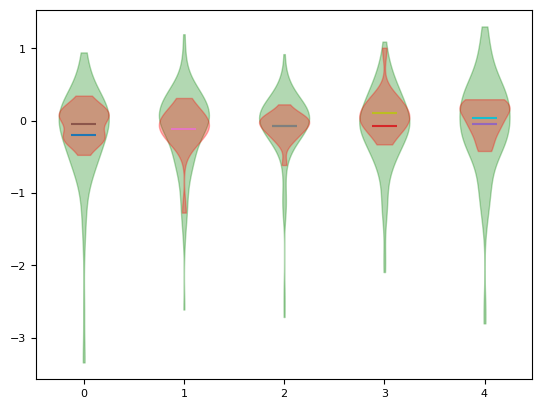

In [42]:


datasets = [np.array(epoch_segments_excitatory_mean),
              np.array(epoch_segments_inhibitory_mean)]
colors = ['green', 'red']

for color, dataset in zip(colors, datasets):
    m = np.mean(dataset, axis=0)
    for i, dat in enumerate(dataset):
        vp = plt.violinplot(
            np.log2(dat/m),
            positions=[i],
            showmeans=True,
            showmedians=False,
            showextrema=False,
            widths=0.5,
        )
        # color = 'green'
        for body in vp['bodies']:
            body.set_facecolor(color)
            body.set_edgecolor(color)
            body.set_alpha(0.3)

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7fc6ae671480>],
 'cmeans': <matplotlib.collections.LineCollection at 0x7fc6ae6726e0>}

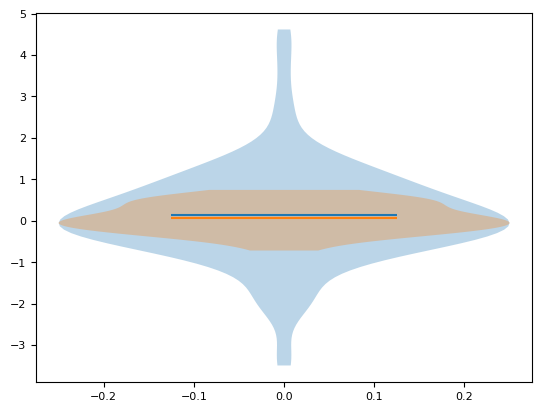

In [34]:
dat = epoch_segments_excitatory_mean[-1] / epoch_segments_excitatory_mean[0]
plt.violinplot(
    np.log2(dat),
    positions=[0],
    showmeans=True,
    showmedians=False,
    showextrema=False,
    widths=0.5,
)

dat = epoch_segments_inhibitory_mean[-1] / epoch_segments_inhibitory_mean[0]
plt.violinplot(
    np.log2(dat),
    positions=[0],
    showmeans=True,
    showmedians=False,
    showextrema=False,
    widths=0.5,
)

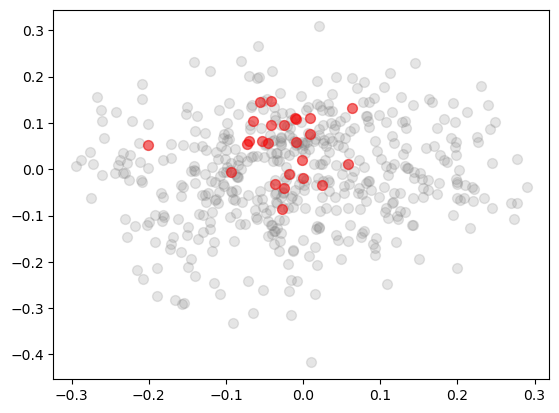

In [25]:
len(significant_idx)
plt.scatter(W_dim[:,0], W_dim[:,1],c="grey",s=s,alpha=.2)
plt.scatter(W_dim[significant_idx,0], W_dim[significant_idx,1],c='r',s=s,alpha=.5)

# Per trial spike count vs. motivation

In [272]:
results = {
    "excitatory": {id:[] for id in ind_neuron_type["excitatory"]},
    "inhibitory": {id:[] for id in ind_neuron_type["inhibitory"]},
    "all": {id:[] for id in range(len(spikes))}
}
ind_ambig = np.arange(len(spikes))
ind_ambig = np.setdiff1d(ind_ambig, np.concatenate([ind_neuron_type["excitatory"], ind_neuron_type["inhibitory"]]))
from tqdm import tqdm
for i, trial in tqdm(trial_df.iterrows(), total=trial_df.shape[0]):
    trial_start = trial["run_start"] - 1
    trial_end = trial["t_poke"] + 1
    duration = trial_end - trial_start
    for neuron_type in ["excitatory", "inhibitory"]:
        for ind_neuron in ind_neuron_type[neuron_type]:
            st = np.digitize(trial_start, spikes[ind_neuron]) - 1
            en = np.digitize(trial_end, spikes[ind_neuron][st:])
            results[neuron_type][ind_neuron].append(en/duration)
            # results["all"][ind_neuron].append(en)

    for ind_neuron in np.arange(len(spikes)):
        st = np.digitize(trial_start, spikes[ind_neuron]) - 1
        en = np.digitize(trial_end, spikes[ind_neuron][st:])
        results["all"][ind_neuron].append(en/duration)

100%|██████████| 1416/1416 [01:45<00:00, 13.47it/s]


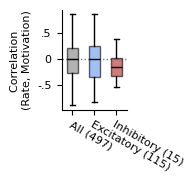

In [284]:
corr_inhib = []
for i, neuron in enumerate(results["inhibitory"].values()):
    ind = ~np.isnan(trial_df.motivation.values) & ~np.isnan(neuron)
    corr_inhib.append(np.corrcoef(trial_df.motivation.values[ind], np.array(neuron)[ind])[0,1])

corr_excit = []
for i, neuron in enumerate(results["excitatory"].values()):
    ind = ~np.isnan(trial_df.motivation.values) & ~np.isnan(neuron)
    corr_excit.append(np.corrcoef(trial_df.motivation.values[ind], np.array(neuron)[ind])[0,1])

corr_all = []
for i, neuron in enumerate(results["all"].values()):
    ind = ~np.isnan(trial_df.motivation.values) & ~np.isnan(neuron)
    corr_all.append(np.corrcoef(trial_df.motivation.values[ind], np.array(neuron)[ind])[0,1])


fig = plt.figure(figsize=(.85,1.3))
ax = fig.add_subplot(111)
# plt.boxplot([corr_inhib, corr_excit],
#             labels=[f"Excitatory \n(n={len(corr_inhib)})", f"Inhibitory \n(n={len(corr_excit)})"],
#             patch_artist=True,
#             boxprops=dict(facecolor="lightblue")
# )
bp = ax.boxplot(
    [corr_all, corr_excit, corr_inhib],
    # labels=[
    #     f"Excitatory \n(n={len(corr_inhib)})",
    #     f"Inhibitory \n(n={len(corr_excit)})",
    # ],
    patch_artist=True,
    medianprops=dict(color="black", ),
    widths=0.5,
)

box_colors = ['grey', neuron_colors["excitatory"], neuron_colors["inhibitory"]]

for box, color in zip(bp["boxes"], box_colors):
    box.set_facecolor(color, )
    box.set_alpha(0.6)
ax.axhline(0, color="grey", linestyle=":", linewidth=1, zorder = -2)
# ax.set_ylabel("C(spike count, motivation)", fontsize=8)
ax.set_ylabel("Correlation \n(Rate, Motivation)", fontsize=8)
ax.set_yticks([-0.5, 0, 0.5], ["-.5", "0", ".5"])
ax.spines[["top", "right"]].set_visible(False)

# labels=[
#         f"Excitatory \n(n={len(corr_inhib)})",
#         f"Inhibitory \n(n={len(corr_excit)})",
#     ]
labels = ["All", "Excitatory", "Inhibitory"]
labels = [f"All ({len(corr_all)})", f"Excitatory ({len(corr_excit)})", f"Inhibitory ({len(corr_inhib)})"]
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(labels, fontsize=8, rotation=-30, ha='left',rotation_mode='anchor')
plt.rcParams['svg.fonttype'] = 'none'
fig.savefig(fig_dir / f"neuron_motivation_correlation_boxplot.svg", dpi=300, bbox_inches="tight")

In [278]:
len(ind_neuron_type["excitatory"]), len(ind_neuron_type["inhibitory"]), len(ind_ambig), len(spikes)

(115, 15, 367, 497)

In [ ]:
len(corr_inhib),

(115,)

In [279]:
len(results["excitatory"]), len(results["inhibitory"]), len(results["all"])

(115, 15, 497)

In [88]:
from scipy.stats import ttest_ind

test_result = ttest_ind(corr_inhib, corr_excit, equal_var=False, nan_policy="omit")
print(f"Welch's t-test: t={test_result.statistic:.3f}, p={test_result.pvalue:.4g}")


Welch's t-test: t=1.914, p=0.05914


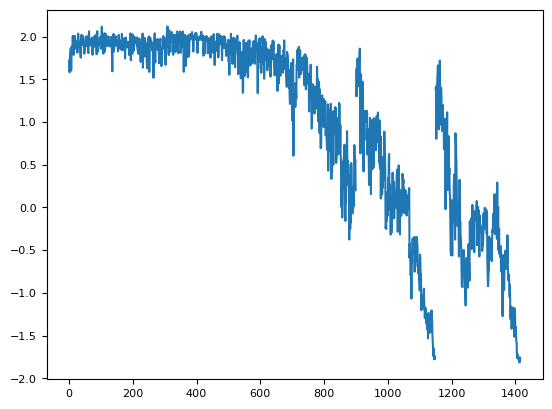

In [68]:
plt.plot(trial_df.motivation.values)

# Motivation Angle + Reward Rate Scatter

In [67]:
mot_pc_vals = []
trial_rate = []
reward_rate = []
t_bin = []
epoch_bin = []

bin_size = 60.0 # seconds
bin_step = 5.0 # seconds
dt = .001

ind_size = int(bin_size/dt)
ind_step = int(bin_step/dt)
from tqdm import tqdm
for i_ep, (st, en) in tqdm(enumerate(run_epochs)):
    st = st+60
    en = en-60
    epoch_interval = [st, en]
    ind_epoch = interval_list_contains_ind(np.array([epoch_interval]), analysis.t_interp)
    st = ind_epoch[0]#+60
    while st < ind_epoch[-1]:
        en = st + ind_size
        if en > ind_epoch[-1]:
            break
        t_st = analysis.t_interp[st]
        t_en = analysis.t_interp[en]
        if t_en > epoch_interval[1]:
            break
        t_bin.append((t_st+t_en)/2)
        mot_pc_vals.append(np.mean(analysis.c_pca_interp[st:en, motivation_pcs], axis=0))

        ind_trial = np.where((trial_df["t_poke"] >= t_st) & (trial_df["t_poke"] < t_en))[0]
        trial_rate.append(len(ind_trial)/bin_size*60)
        n_rewards = np.sum(trial_df["reward"].iloc[ind_trial])
        reward_rate.append(n_rewards/bin_size*60)
        epoch_bin.append(i_ep)

        st += ind_step

mot_pc_vals = np.array(mot_pc_vals)
trial_rate = np.array(trial_rate)
reward_rate = np.array(reward_rate)
epoch_bin = np.array(epoch_bin)
t_bin = np.array(t_bin)

5it [00:02,  2.14it/s]


Text(0, 0.5, 'Trial Rate ($min^{-1}$)')

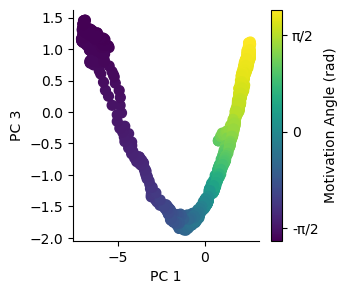

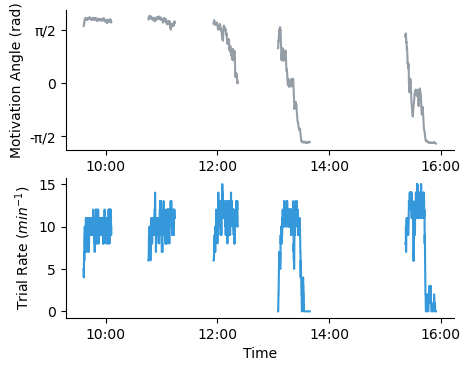

In [ ]:
mot_angle = np.arctan2(mot_pc_vals[:,0], -mot_pc_vals[:,1])

fig1 = plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)
ax1.spines[["top", "right"]].set_visible(False)
plt.scatter(mot_pc_vals[:,0], mot_pc_vals[:,1], c=mot_angle, cmap="viridis", s=50)
plt.xlabel(f"PC {motivation_pcs[0]+1}")
plt.ylabel(f"PC {motivation_pcs[1]+1}")
cb = plt.colorbar(label="Motivation Angle (rad)")
cb.ax.set_yticks([ -np.pi/2, 0, np.pi/2,],)
cb.ax.set_yticklabels([ "-π/2", "0", "π/2"])



#
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(211)
ax_trial = fig.add_subplot(212, sharex=ax)
ax.spines[["top", "right"]].set_visible(False)
ax_trial.spines[["top", "right"]].set_visible(False)
# ax.scatter(t_bin, mot_angle)
for i in np.unique(epoch_bin):
    ind = np.where(epoch_bin == i)[0]
    ax.plot(t_bin[ind], mot_angle[ind], color="#2c3e50", alpha=0.5)
ax.set_yticks([-np.pi/2, 0, np.pi/2], ["-π/2", "0", "π/2"])
dt = datetime.fromtimestamp(t_bin[0])
new_dt = []
for hour in (10,12,14,16):
    new_dt.append(dt.replace(hour=hour, minute=0, second=0))
tick_labels = [datetime.strftime(dt, "%H:%M") for dt in new_dt]
tick_times = [dt.timestamp() for dt in new_dt]
ax.set_xticks(tick_times, tick_labels)
plt.xlabel("Time")
ax.set_ylabel("Motivation Angle (rad)")

# ax_trial.scatter(t_bin, trial_rate, color="#3498db", alpha=0.5, s=20)
for i in np.unique(epoch_bin):
    ind = np.where(epoch_bin == i)[0]
    ax_trial.plot(t_bin[ind], trial_rate[ind], color="#3498db")
ax_trial.set_ylabel("Trial Rate ($min^{-1}$)")

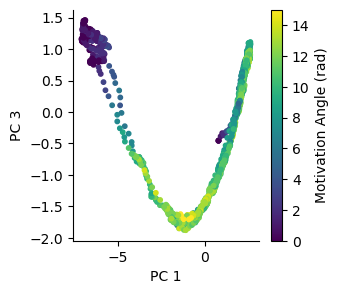

In [ ]:
fig1 = plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)
ax1.spines[["top", "right"]].set_visible(False)
plt.scatter(mot_pc_vals[:,0], mot_pc_vals[:,1], c=trial_rate, cmap="viridis", s=10)
plt.xlabel(f"PC {motivation_pcs[0]+1}")
plt.ylabel(f"PC {motivation_pcs[1]+1}")
cb = plt.colorbar(label="Motivation Angle (rad)")
# cb.ax.set_yticks([ -np.pi/2, 0, np.pi/2,],)
# cb.ax.set_yticklabels([ "-π/2", "0", "π/2"])

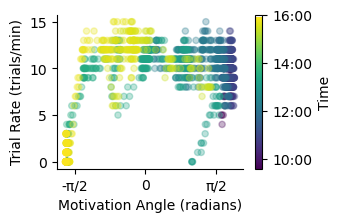

In [109]:
fig = plt.figure(figsize=(3,2))
ax = fig.add_subplot(111)
plt.scatter(mot_angle, trial_rate, c=t_bin, cmap="viridis", s=20, alpha = .3)

plt.xlabel("Motivation Angle (radians)")
plt.ylabel("Trial Rate (trials/min)")
cb = plt.colorbar(label="Time")

from datetime import datetime
st = datetime.fromtimestamp(t_bin[10])
en = datetime.fromtimestamp(t_bin[-1])

dt = datetime.fromtimestamp(t_bin[0])
new_dt = []
for hour in (10,12,14,16):
    new_dt.append(dt.replace(hour=hour, minute=0, second=0))
tick_labels = [datetime.strftime(dt, "%H:%M") for dt in new_dt]
tick_times = [dt.timestamp() for dt in new_dt]

cb.ax.set_yticks(tick_times)
cb.ax.set_yticklabels(tick_labels)
# `cb.solids_patches` is a list in newer matplotlib versions, so set alpha on the actual artist(s)
for collection in cb.ax.collections:
    collection.set_alpha(1)

ax.set_xticks([-np.pi/2, 0, np.pi/2], ["-π/2", "0", "π/2"])
ax.spines[["top", "right"]].set_visible(False)
# plt.xscale("log")

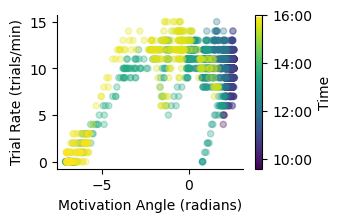

In [117]:
fig = plt.figure(figsize=(3,2))
ax = fig.add_subplot(111)

norm_mot_angle = mot_angle - np.min(mot_angle)
norm_mot_angle = norm_mot_angle / np.max(norm_mot_angle)


norm_mot_angle = mot_pc_vals[:,0] #- np.min(mot_pc_vals[:,0])
# norm_mot_angle = mot_pc_vals[:,1] - np.min(mot_pc_vals[:,1])
# norm_mot_angle = norm_mot_angle / np.max(norm_mot_angle)

plt.scatter(norm_mot_angle, trial_rate, c=t_bin, cmap="viridis", s=20, alpha = .3)

plt.xlabel("Motivation Angle (radians)")
plt.ylabel("Trial Rate (trials/min)")
cb = plt.colorbar(label="Time")

from datetime import datetime
st = datetime.fromtimestamp(t_bin[10])
en = datetime.fromtimestamp(t_bin[-1])

dt = datetime.fromtimestamp(t_bin[0])
new_dt = []
for hour in (10,12,14,16):
    new_dt.append(dt.replace(hour=hour, minute=0, second=0))
tick_labels = [datetime.strftime(dt, "%H:%M") for dt in new_dt]
tick_times = [dt.timestamp() for dt in new_dt]

cb.ax.set_yticks(tick_times)
cb.ax.set_yticklabels(tick_labels)
# `cb.solids_patches` is a list in newer matplotlib versions, so set alpha on the actual artist(s)
for collection in cb.ax.collections:
    collection.set_alpha(1)

# ax.set_xticks([-np.pi/2, 0, np.pi/2], ["-π/2", "0", "π/2"])
ax.spines[["top", "right"]].set_visible(False)
# plt.xscale("log")

## Motivation Angle + Switch probability

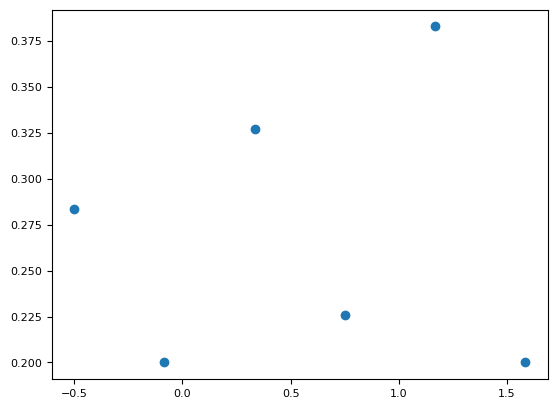

In [256]:
df = trial_df.copy()
df = df[df.prev_trial_reward==0]
# mot_bins = np.linspace(-np.pi/2, np.pi/2, 4)
mot_bins = np.nanpercentile(df.motivation.values, np.linspace(10,90,10))
mot_bins = np.linspace(-.5,2,7)
switch_p = []
for i in range(len(mot_bins)-1):
    ind = df.motivation.values >= mot_bins[i]
    ind &= df.motivation.values < mot_bins[i+1]
    switch_p.append(np.mean(df["n_pre_switch"].values[ind]==0))

plt.scatter(mot_bins[:-1], switch_p)


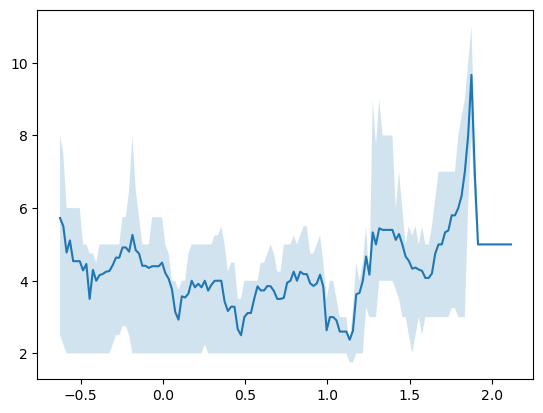

In [30]:
min_mot = -.5
max_mot = 3

width = .5
step = .02

df = trial_df.copy()
# df = df[df.prev_trial_reward==1]
df = df[df.epoch >= 6]
df = df[df.n_post_switch==1]
# plt.hist(df_i.n_pre_switch)

xx = []
yy = []
lo = []
hi = []
for i in range(int((max_mot-min_mot)/step)):
    st = min_mot + i*step - width/2
    en = st + width/2
    ind = df.motivation.values >= st
    ind &= df.motivation.values < en
    xx.append((st+en)/2)
    # yy.append(np.mean(df["n_pre_switch"].values[ind]==0))
    yy.append(np.mean(df["n_pre_switch"].values[ind]))
    lo.append(np.nanpercentile(df["n_pre_switch"].values[ind], 25))
    hi.append(np.nanpercentile(df["n_pre_switch"].values[ind], 75))
plt.plot(xx, yy)
plt.fill_between(xx, lo, hi, alpha=.2)

In [29]:
lo

np.float64(nan)

In [11]:
df.epoch.unique()

array([ 4,  6,  8, 10])

177
191
205
219
234
248
262
276
291
305
319
333
348
353
352
352
353
353
352
352
353
353
352
352
353
353
352
352
353
353
352
352
353
353
353
352
352
353
353
352
352
353
353
352
352
353
353
352
352
353
353
352
352
353
353
352
352
353
353
352
352
353
353
352
352
353
353
353
352
352
353
353
352
352
353
353
352
352
353
353
352
352
353
353
352
352
353
347
332
318
304
290
275
261
247
233
218
204
190
176


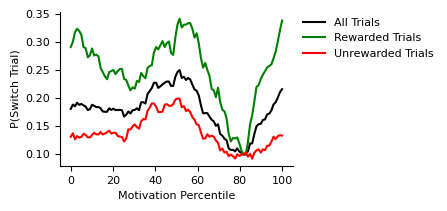

In [ ]:
mot_percentile_centers = np.linspace(0,100, 100)
mot_percentile_width = 25

motivation = trial_df.motivation.values
p_switch_all = []
p_switch_rewarded = []
p_switch_unrewarded = []
for j in range(len(mot_percentile_centers)):
    mot_min = np.nanpercentile(motivation, max(0, mot_percentile_centers[j] - mot_percentile_width/2))
    mot_max = np.nanpercentile(motivation, min(100, mot_percentile_centers[j] + mot_percentile_width/2))
    ind = (motivation >= mot_min) & (motivation < mot_max)
    print(np.sum(ind))
    df = trial_df[ind]

    p_switch_all.append(np.mean(df["n_pre_switch"].values==0))
    ind_rewarded = df.reward.values==1
    p_switch_rewarded.append(np.mean(df["n_pre_switch"].values[ind_rewarded]==0))
    ind_unrewarded = df.reward.values==0
    p_switch_unrewarded.append(np.mean(df["n_pre_switch"].values[ind_unrewarded]==0))

fig =plt.figure(figsize=(3,2))
ax = fig.add_subplot(111)
plt.plot(mot_percentile_centers, p_switch_all, color="black", label="All Trials")
plt.plot(mot_percentile_centers, p_switch_rewarded, color="green", label="Rewarded Trials")
plt.plot(mot_percentile_centers, p_switch_unrewarded, color="red", label="Unrewarded Trials")
plt.xlabel("Motivation Percentile")
plt.ylabel("P(Switch Trial)")
fig.legend(
    loc="upper left",
    bbox_to_anchor=(0.9, 0.9),
    frameon=False,
    fontsize=8
)
ax.spines[["top", "right"]].set_visible(False)
fig.savefig(fig_dir / f"motivation_switch_probability.svg", dpi=300, bbox_inches="tight")

# Motivation Angle vs Q stem threshold for switch

0
0
0
0
0
0


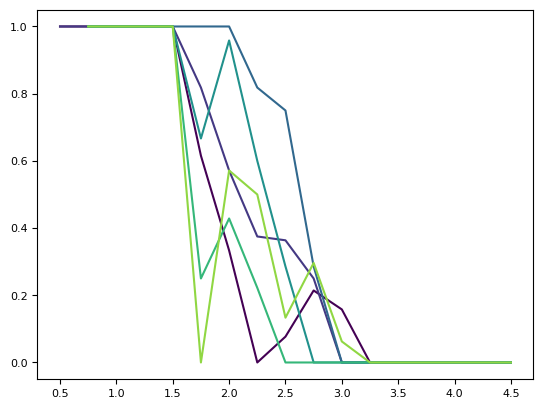

In [ ]:

mot_q_thresh = []
mot_bins = np.linspace(-.5, 2, 10)

mot_percentiles = np.linspace(0, 100, 7)
mot_bins = np.nanpercentile(trial_df.motivation.values, mot_percentiles)

for j in range(len(mot_bins)-1):
    ind = trial_df.motivation.values >= mot_bins[j]
    ind &= trial_df.motivation.values < mot_bins[j+1]
    df = trial_df[ind]
    color = plt.cm.viridis(j/(len(mot_bins)-1))


    q_bins = np.arange(0,5,.25)
    yy = np.empty(q_bins.shape[0]-1)
    for i in range(len(q_bins)-1):
        ind = df.Q_stem_trial.values >= q_bins[i]
        ind &= df.Q_stem_trial.values < q_bins[i+1]
        yy[i] = np.nanmean(df["n_pre_switch"].values[ind]==0)

    plt.plot(q_bins[:-1], yy, color=color, label=f"Motivation {mot_bins[j]:.2f}-{mot_bins[j+1]:.2f}")
    ind = ~np.isnan(yy)
    yy = yy[ind]
    q_bins = q_bins[:-1][ind]
    print(np.argmin(yy<.5))
    mot_q_thresh.append(q_bins[np.min(np.where(yy<.5))])

array([1.        , 1.        , 1.        , 1.        , 0.        ,
       0.57142857, 0.5       , 0.13333333, 0.2962963 , 0.0625    ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        ])

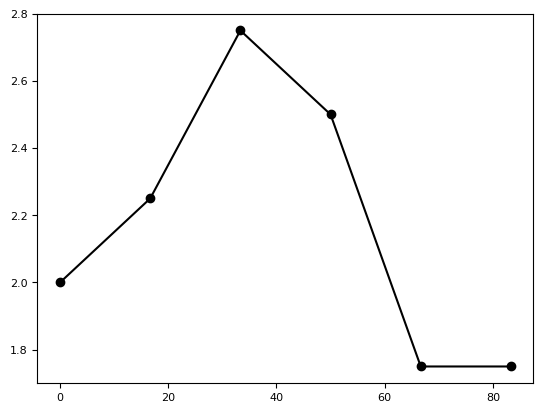

In [226]:
# plt.plot(mot_bins[:-1], mot_q_thresh, color="black", marker="o")
plt.plot(mot_percentiles[:-1], mot_q_thresh, color="black", marker="o")
yy

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/tmp/ipykernel_1765547/2817696196.py:11: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(sigmoid, xx, yy, p0=initial_guess)


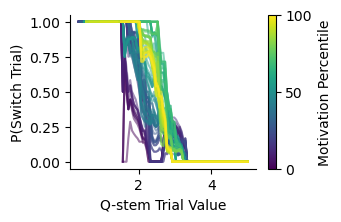

In [33]:
mot_q_thresh = []
df_restricted = trial_df.copy()
df_restricted = df_restricted[df_restricted.epoch >= 6]

mot_percentile_centers = np.linspace(0,100, 100)
mot_percentile_width = 20

q_centers = np.linspace(0, 5, 100)
q_widths = .5

mot_q_thresh = []
motivation = df_restricted.motivation.values

fig, ax = plt.subplots(figsize=(3,2))
ax.spines[["top", "right"]].set_visible(False)
for j in range(len(mot_percentile_centers)):
    mot_min = np.nanpercentile(motivation, max(0, mot_percentile_centers[j] - mot_percentile_width/2))
    mot_max = np.nanpercentile(motivation, min(100, mot_percentile_centers[j] + mot_percentile_width/2))
    ind = (motivation >= mot_min) & (motivation < mot_max)
    # print(np.sum(ind))
    df = df_restricted[ind]

    yy = np.empty(q_centers.shape[0])
    n_trials = np.empty(q_centers.shape[0])
    for i in range(len(q_centers)):
        q_min = q_centers[i] - q_widths/2
        q_max = q_centers[i] + q_widths/2
        ind_q = (df.Q_stem_trial.values >= q_min) & (df.Q_stem_trial.values < q_max)
        switch_prob = np.nanmean(df["n_pre_switch"].values[ind_q]==0)
        yy[i] = switch_prob
        n_trials[i] = np.sum(ind_q)

    ax.plot(q_centers, yy, color=plt.cm.viridis(j/(len(mot_percentile_centers)-1)), alpha=0.5,
            label=f"Motivation {mot_min:.2f}-{mot_max:.2f}")

    xx = np.min(np.where(yy<.5))
    mot_thresh_i = get_sigmoid_threshold(q_centers, yy, threshold=0.5)
    # mot_thresh_i = q_centers[xx] if xx < len(q_centers) else np.nan
    # mot_thresh_i = fit_switch_sigmoid(q_centers, yy, n_trials)[1]
    mot_q_thresh.append(mot_thresh_i)
    # mot_q_thresh.append(q_centers[xx] if xx < len(q_centers) else np.nan)
plt.xlabel("Q-stem Trial Value")
plt.ylabel("P(Switch Trial)")
# ax.legend()
cb = plt.colorbar(plt.cm.ScalarMappable(cmap="viridis"), label="Motivation Percentile", ax=ax)
cb.set_ticks([0, 0.5, 1])
cb.set_ticklabels(["0", "50", "100"])


In [34]:
def fit_sigmoid(xx, yy):
    from scipy.optimize import curve_fit

    def sigmoid(x, a, b, c, d):
        return a / (1 + np.exp(-b * (x - c))) + d

    # Initial parameter guesses
    initial_guess = [1, 1, np.median(xx), 0]

    # Fit the sigmoid function to the data
    popt, pcov = curve_fit(sigmoid, xx, yy, p0=initial_guess)

    return popt  # Returns the optimized parameters

def get_sigmoid_threshold(xx, yy, threshold=0.5):
    ind = ~np.isnan(yy)
    xx = xx[ind]
    yy = yy[ind]
    popt = fit_sigmoid(xx, yy)
    a, b, c, d = popt

    # Calculate the x-value where the sigmoid crosses the threshold
    threshold_x = c + (1/b) * np.log((a/(threshold - d)) - 1)

    return threshold_x




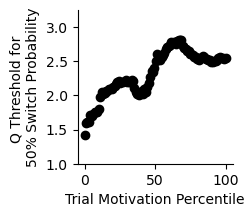

In [38]:
fig, ax = plt.subplots(figsize=(2,2))
plt.scatter(mot_percentile_centers, mot_q_thresh, color="black", marker="o")
plt.xlabel("Trial Motivation Percentile")
plt.ylabel("Q Threshold for \n50% Switch Probability")
ax.spines[["top", "right"]].set_visible(False)

plt.ylim(1, 3.25)
fig.savefig(fig_dir / f"motivation_q_threshold.svg", dpi=300, bbox_inches="tight")